In [2]:
import pandas as pd
df = pd.read_csv('c:/data/ozone/ozone.csv')
df.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5


<Axes: >

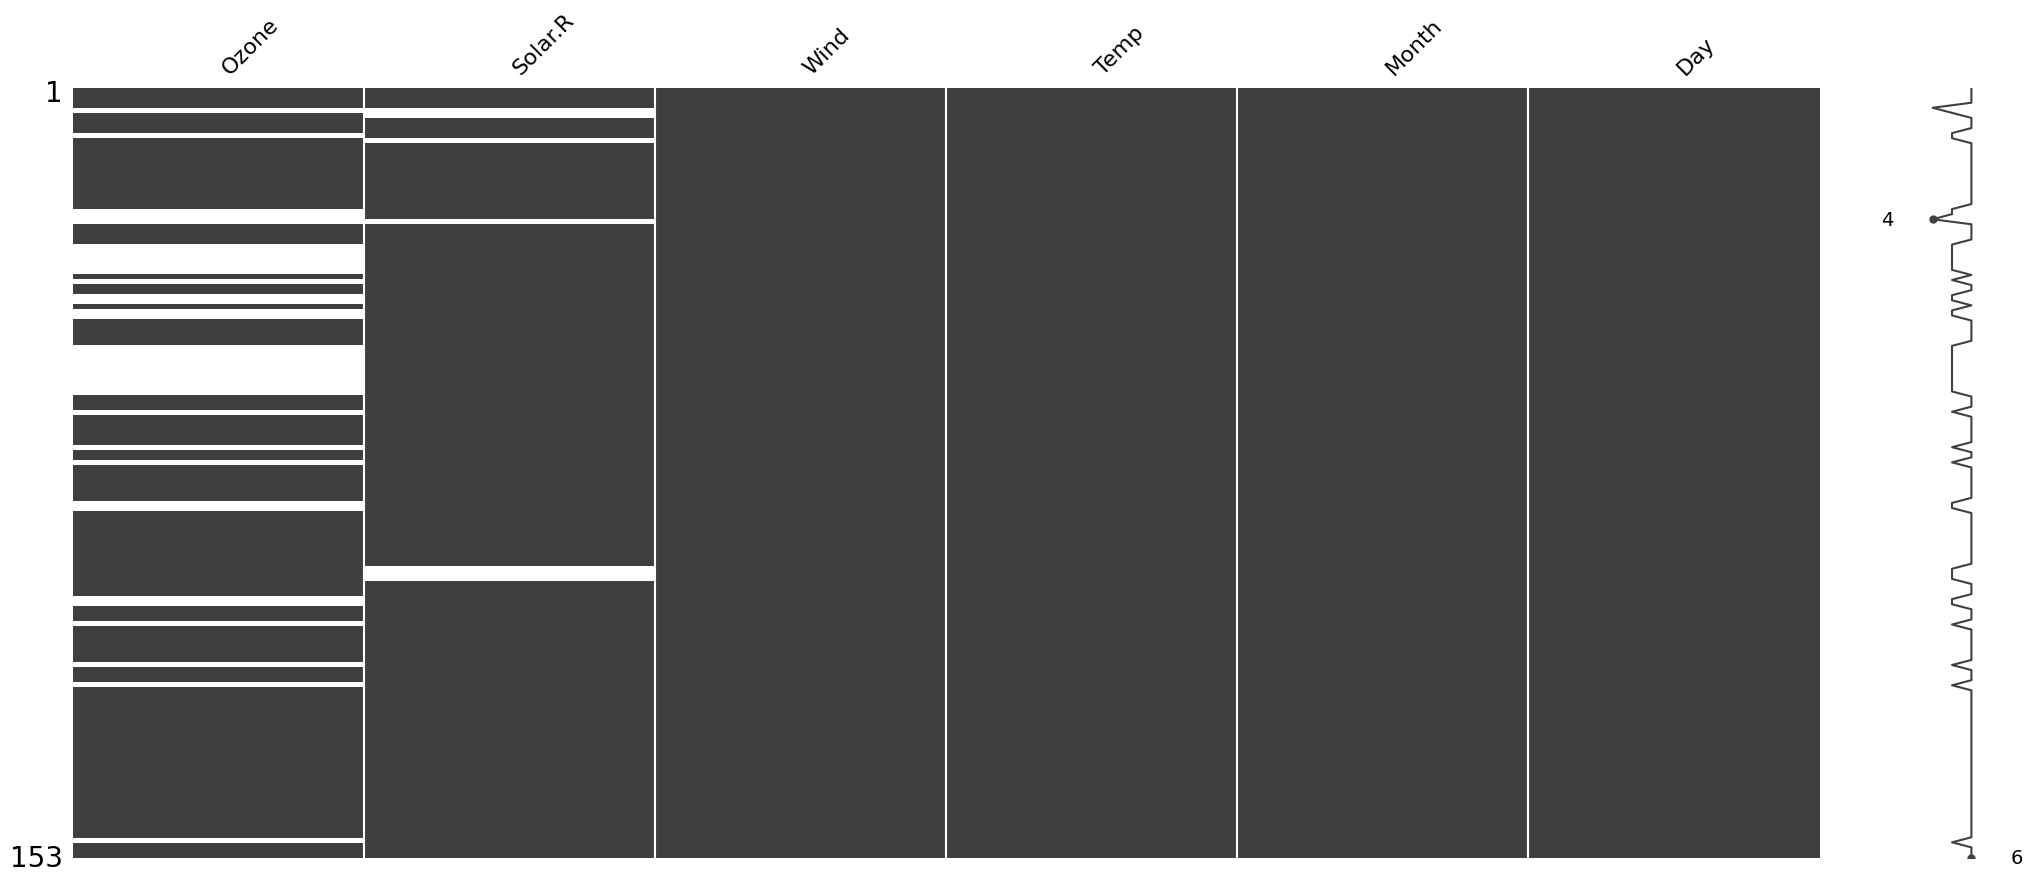

In [3]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)

In [4]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.00000,190.000000,7.4,67.0,5.0,1.0
1,36.00000,118.000000,8.0,72.0,5.0,2.0
2,12.00000,149.000000,12.6,74.0,5.0,3.0
3,18.00000,313.000000,11.5,62.0,5.0,4.0
4,42.12931,185.931507,14.3,56.0,5.0,5.0
...,...,...,...,...,...,...
148,30.00000,193.000000,6.9,70.0,9.0,26.0
149,42.12931,145.000000,13.2,77.0,9.0,27.0
150,14.00000,191.000000,14.3,75.0,9.0,28.0
151,18.00000,131.000000,8.0,76.0,9.0,29.0


<Axes: >

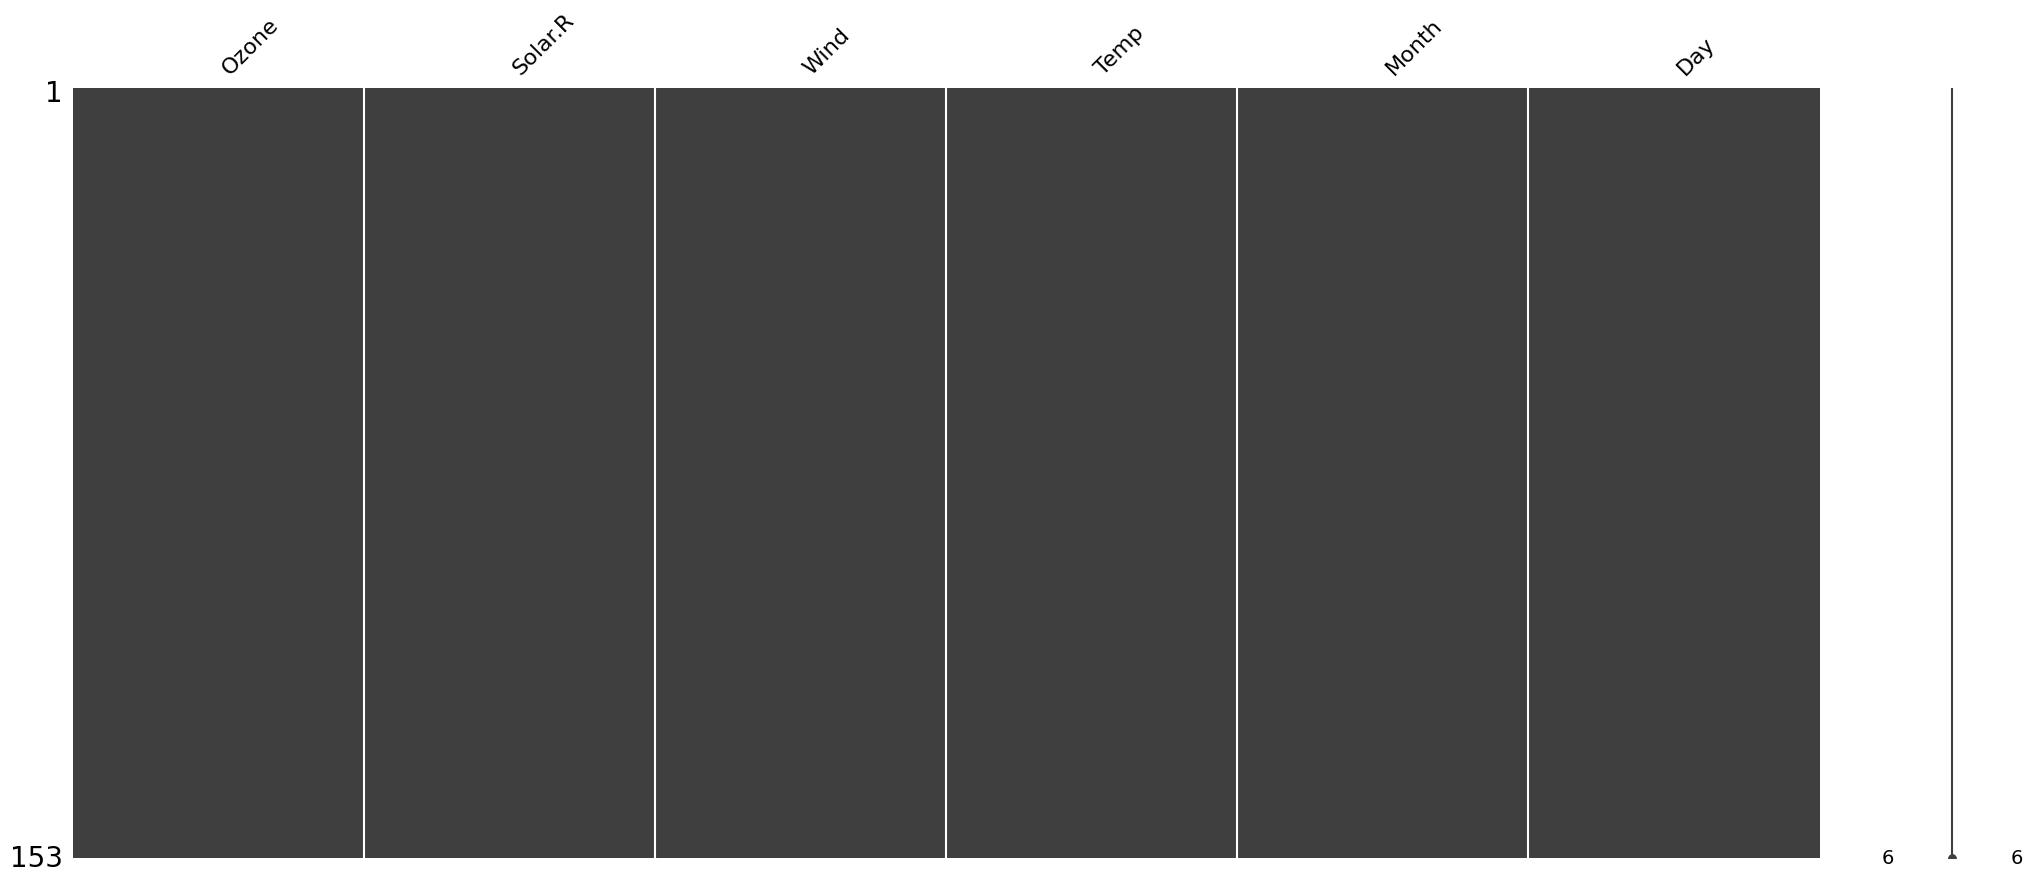

In [5]:
msno.matrix(df)

In [6]:
X = df[['Solar.R','Wind','Temp']]
y = df['Ozone']

In [7]:
import statsmodels.api as sm

model = sm.OLS(y,X)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Ozone   R-squared (uncentered):                   0.831
Model:                            OLS   Adj. R-squared (uncentered):              0.828
Method:                 Least Squares   F-statistic:                              246.7
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                    9.03e-58
Time:                        13:15:06   Log-Likelihood:                         -682.21
No. Observations:                 153   AIC:                                      1370.
Df Residuals:                     150   BIC:                                      1380.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Solar.R        0.0600      0.020      2.969      0.003       0.020       0.100
Wind          -3.4514      0.408     -8.459      0.000      -4.258      -2.645
Temp           0.8430      0.071     11.820      0.000       0.702       0.984
==============================================================================
Omnibus:                       40.837   Durbin-Watson:                   1.639
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               79.840
Skew:                           1.210   Prob(JB):                     4.60e-18
Kurtosis:                       5.581   Cond. No.                         52.5
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
# 일조량, 풍량, 화씨온도 일때의 오존량 예측
result.predict([92,15.5,84])

array([22.82932997])

In [9]:
result.save('c:/data/ozone/ozone_regress.model')

In [10]:
from statsmodels.regression.linear_model import OLSResults
model = OLSResults.load('c:/data/ozone/ozone_regress.model')

In [11]:
model.predict([92,15.5,84])

array([22.82932997])

In [12]:
model.predict([80,5.5,64])

array([39.76437475])